<a href="https://colab.research.google.com/github/serjtankian/practica-keepcoding-NLP-Search/blob/main/NLP_ExploracionDeDatos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from wordcloud import WordCloud
from nltk import ngrams
from nltk.probability import FreqDist
from sklearn.manifold import TSNE
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence
import seaborn as sns
import matplotlib.cm as cm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ruta_real = '/content/drive/MyDrive/reviews_Electronics_5.json.gz'
df = pd.read_json(ruta_real, lines=True)

In [ ]:
df_reducido = df.sample(n=30000, random_state=42)


df_reducido.to_csv('/content/electronics_30k.csv', index=False)

Cardinalidad del vocabulario con One Hot Encoding

In [ ]:

vectorizer = CountVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=50,
    min_df=5,
    max_df=0.8,
    token_pattern=r'\b[a-zA-Z]{3,}\b'
)

X = vectorizer.fit_transform(df_reducido['reviewText'])

In [ ]:

 doc_term_matrix = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
 doc_term_matrix

,amazon,battery,better,bought,buy,cable,camera,card,case,computer,...,unit,usb,use,used,using,video,want,way,work,works
0,1,0,2,1,4,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
29996,0,0,0,0,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
29997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29998,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


N-gramas mas Frecuentes

In [ ]:
vectorizer = CountVectorizer(
    lowercase=True,
    stop_words=['the', 'i', 'and', 'to', 'a', 'it', 'is', 'of', 'this', 'for'],
    ngram_range=(2, 3),
    max_features=50,
    min_df=5,
    max_df=0.8,
    token_pattern=r'\b[a-zA-Z]{3,}\b'
)
X = vectorizer.fit_transform(df_reducido['reviewText'])

In [ ]:
print(vectorizer.get_feature_names_out())

['are not' 'battery life' 'better than' 'but not' 'but that' 'but you'
 'came with' 'comes with' 'did not' 'does not' 'don have' 'easy use'
 'happy with' 'hard drive' 'has been' 'have been' 'have had'
 'highly recommend' 'less than' 'more than' 'much better' 'not have'
 'sound quality' 'that can' 'that was' 'that would' 'that you' 'there are'
 'these are' 'they are' 'very good' 'very happy' 'very well' 'was not'
 'what you' 'when you' 'will not' 'works great' 'works well' 'would have'
 'would not' 'would recommend' 'you are' 'you can' 'you don' 'you get'
 'you have' 'you need' 'you want' 'you will']


In [ ]:
doc_term_matrix = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
doc_term_matrix

,are not,battery life,better than,but not,but that,but you,came with,comes with,did not,does not,...,would not,would recommend,you are,you can,you don,you get,you have,you need,you want,you will
0,0,0,0,0,0,1,0,0,0,0,...,0,0,2,1,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
29996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29997,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
29998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
text = df_reducido['reviewText']
text.head()

,reviewText
981956,"Well, after trying out some Box Towers....that..."
615465,I ordered one for my wife and one for me. Afte...
1060045,muy buen producto... a full en juegos fHD.... ...
248321,The sound quality of this unit is phenomenal. ...
1498033,It is good on keeping your cpu cool also down'...


In [ ]:
 df_reducido = df_reducido.reset_index(drop=True)

 words_nltk = df_reducido['reviewText'].str.lower().str.split()


In [ ]:
words_nltk[:10]

,reviewText
0,"[well,, after, trying, out, some, box, towers...."
1,"[i, ordered, one, for, my, wife, and, one, for..."
2,"[muy, buen, producto..., a, full, en, juegos, ..."
3,"[the, sound, quality, of, this, unit, is, phen..."
4,"[it, is, good, on, keeping, your, cpu, cool, a..."
5,"[well, made,, priced, right, &, works, like, i..."
6,"[this, was, the, right, cable, for, the, right..."
7,"[love, this, keyboard,, it's, the, only, split..."
8,"[i, found, this, keyboard, case, to, be, very,..."
9,"[i, purchased, this, wall, hanger, for, a, son..."


In [ ]:
todas_las_palabras = [palabra for fila in words_nltk.dropna() for palabra in fila]

wf = Counter(todas_las_palabras)

In [ ]:
wf_most_common = wf.most_common(10)
print(wf_most_common)

[('the', 179931), ('i', 93413), ('and', 92426), ('to', 92301), ('a', 89487), ('it', 66721), ('is', 56980), ('of', 47837), ('this', 45682), ('for', 45245)]


In [ ]:
words = [w[0] for w in wf_most_common]
freqs = [w[1] for w in wf_most_common]

In [ ]:
freqs, words = zip(*sorted(zip(freqs, words)))


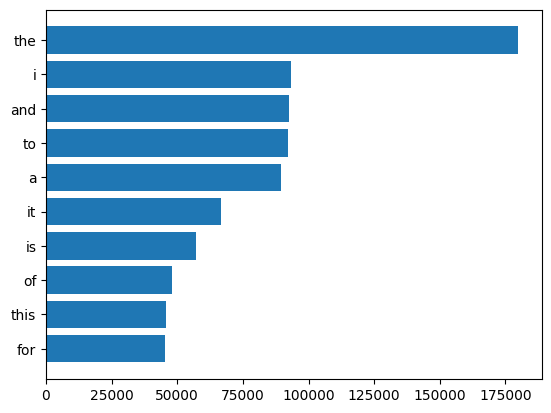

In [ ]:
plt.barh(words, freqs)
plt.show()

In [ ]:
bigrams_ = list(ngrams(todas_las_palabras, 2))
trigrams_ = list(ngrams(todas_las_palabras, 3))

In [ ]:
bigrams_[:10]

[('well,', 'after'),
 ('after', 'trying'),
 ('trying', 'out'),
 ('out', 'some'),
 ('some', 'box'),
 ('box', 'towers....that'),
 ('towers....that', 'sounded'),
 ('sounded', 'like'),
 ('like', 'music'),
 ('music', 'in')]

In [ ]:
trigrams_[:10]

[('well,', 'after', 'trying'),
 ('after', 'trying', 'out'),
 ('trying', 'out', 'some'),
 ('out', 'some', 'box'),
 ('some', 'box', 'towers....that'),
 ('box', 'towers....that', 'sounded'),
 ('towers....that', 'sounded', 'like'),
 ('sounded', 'like', 'music'),
 ('like', 'music', 'in'),
 ('music', 'in', 'a')]

In [ ]:
bg_freq = FreqDist(bigrams_)
tg_freq = FreqDist(trigrams_)

In [ ]:
bg_freq_most_common = bg_freq.most_common(10)
bgs_ = [str(bg[0]) for bg in bg_freq_most_common]
bgs_f_ = [bg[1] for bg in bg_freq_most_common]

tg_freq_most_common = tg_freq.most_common(10)
tgs_ = [str(tg[0]) for tg in tg_freq_most_common]
tgs_f_ = [tg[1] for tg in tg_freq_most_common]

In [ ]:
bgs_f_, bgs_ = zip(*sorted(zip(bgs_f_, bgs_)))
tgs_f_, tgs_ = zip(*sorted(zip(tgs_f_, tgs_)))

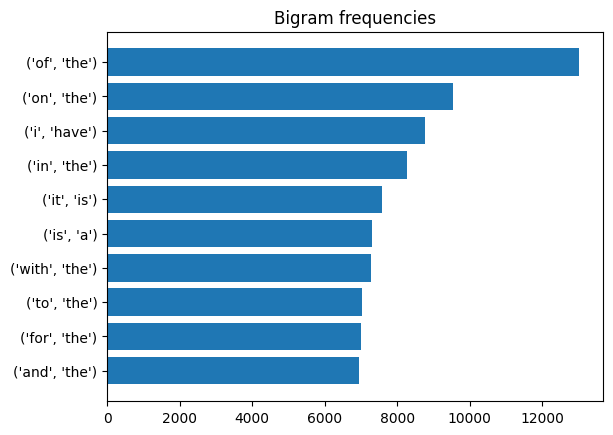

In [ ]:
plt.barh(bgs_, bgs_f_)
plt.title('Bigram frequencies')
plt.show()

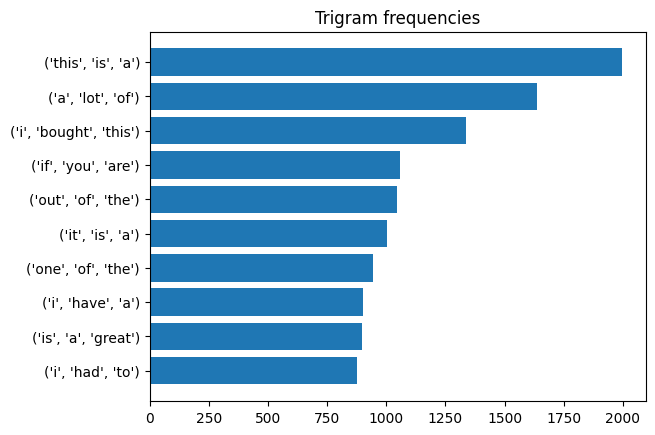

In [ ]:
plt.barh(tgs_, tgs_f_)
plt.title('Trigram frequencies')
plt.show()

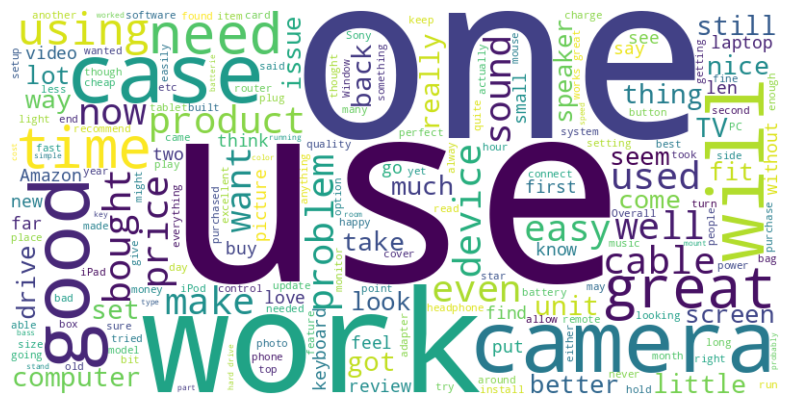

In [ ]:
texto_para_nube = " ".join(df_reducido['reviewText'].dropna().astype(str))

nube = WordCloud(width=800, height=400, background_color='white').generate(texto_para_nube)

plt.figure(figsize=(10, 5))
plt.imshow(nube, interpolation='bilinear')
plt.axis('off')
plt.show()

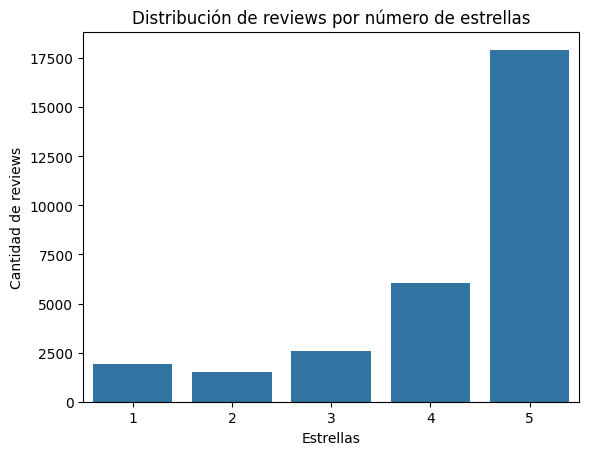

In [ ]:

df = df_reducido

sns.countplot(data=df, x="overall")

plt.title("Distribución de reviews por número de estrellas")
plt.xlabel("Estrellas")
plt.ylabel("Cantidad de reviews")

plt.show()

In [ ]:
df["sentiment"] = df["overall"].apply(
    lambda x: "Positiva" if x >= 4 else "Negativa"
)

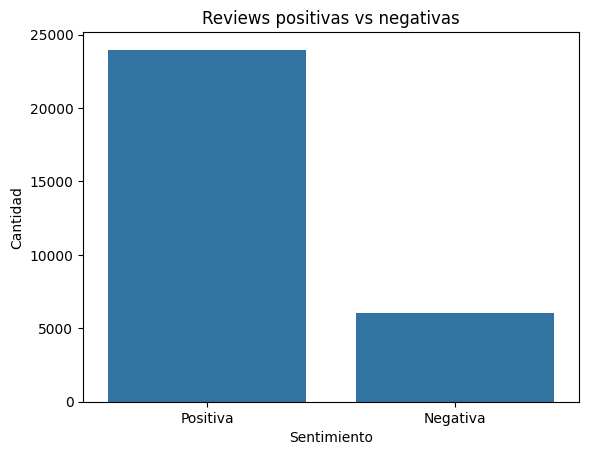

In [ ]:
sns.countplot(data=df, x="sentiment")

plt.title("Reviews positivas vs negativas")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad")

plt.show()

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 31.0 MB/s eta 0:00:00


In [ ]:
textos_entrenamiento = words_nltk.dropna().tolist()
w2v_sg = Word2Vec(
    sentences=textos_entrenamiento,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

w2v_sg.save('w2v_model.pkl')

In [ ]:
w2v_sg.wv.most_similar('usb')

[('2.0', 0.8560787439346313),
 ('3.0', 0.8546160459518433),
 ('(usb', 0.805708646774292),
 ('microusb', 0.8051140904426575),
 ('esata', 0.7994109988212585),
 ('usb3', 0.7976095080375671),
 ('hub,', 0.7910489439964294),
 ('firewire', 0.7897093892097473),
 ('port.', 0.7861901521682739),
 ('usb.', 0.785441517829895)]

In [ ]:
keys = [
    "enjoy",
    "upset",
    "camera",
    "screen",
    "quality",
    "price",
    "sound",
    "product",
    "problem"
]

embedding_clusters = []
word_clusters = []
for word in keys:
    embeddings = []
    words = []
    for similar_word, _ in w2v_sg.wv.most_similar(word, topn=10):
        words.append(similar_word)
        embeddings.append(w2v_sg.wv[similar_word])
    embedding_clusters.append(embeddings)
    word_clusters.append(words)

In [ ]:
print(word_clusters)

[['enjoying', 'collection,', 'listens', 'audiobooks', 'enjoys', 'enjoy.', 'watch,', 'explore', "she's", 'football'], ['cautious', 'scared', 'happy!', 'optimistic', 'frustrated.', 'paranoid', 'unsure', 'disappointed,', 'annoyed', 'sorry.'], ['camera,', 'camera.', 'lense', 'lens', 'camcorder', 'dslr', 'slr', 'dslr.', 'speedlight', 's90'], ['protector', 'screen.', 'screen,', 'lcd', 'anti-glare', 'film.', 'protector.', 'display', 'display.', 'glossy'], ['quality,', 'quality.', 'fidelity', 'quality!', 'phenomenal', 'mediocre', 'fantastic,', 'clarity', 'high-quality', 'quality.i'], ['price,', 'price.', 'price!', 'value', 'pricing', 'cost.', 'paid.', 'cost,', 'price...', '$25'], ['sound.', 'sound,', 'bass', 'audio', 'sounds', 'acoustics', 'soundstage', 'isolation', 'bass,', 'sounding'], ['item', 'product,', 'product.', 'item.', 'seller.', 'vendor.', 'thanks.', 'seller', 'product...', 'item!'], ['issue', 'problem,', 'issues', 'problems', 'problem.', 'disappointment', 'concern', 'troubles', 'di

In [ ]:
tsne_model_2d = TSNE(perplexity=15, n_components=2, init='pca', n_iter=3500, random_state=32)

In [ ]:
embedding_clusters = np.array(embedding_clusters)
n, m, k = embedding_clusters.shape

In [ ]:
embeddings_2d = np.array(tsne_model_2d.fit_transform(embedding_clusters.reshape(n * m, k))).reshape(n, m, 2)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


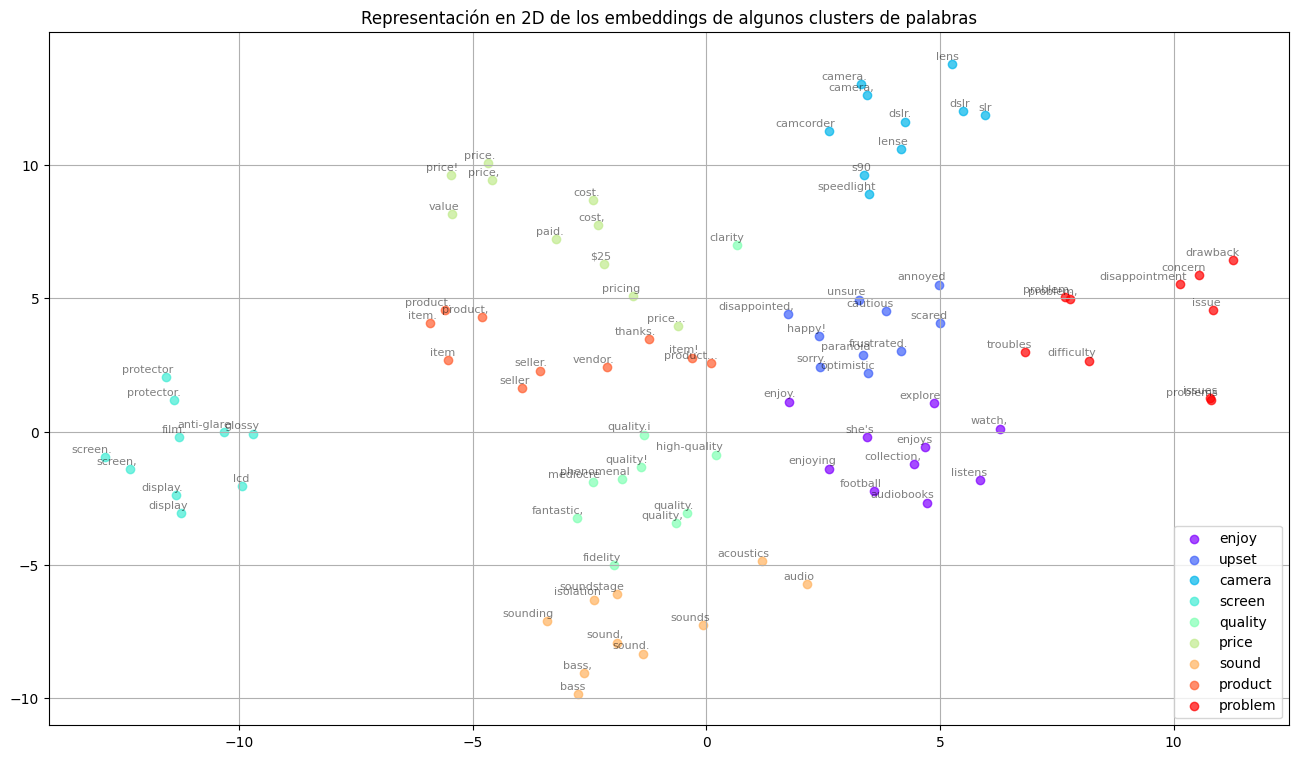

In [ ]:

%matplotlib inline


def tsne_plot_similar_words(labels, embedding_clusters, word_clusters, a=0.7):
    plt.figure(figsize=(16, 9))
    colors = cm.rainbow(np.linspace(0, 1, len(labels)))
    for label, embeddings, words, color in zip(labels, embedding_clusters, word_clusters, colors):
        x = embeddings[:,0]
        y = embeddings[:,1]
        plt.scatter(x, y, c=[color], alpha=a, label=label)
        for i, word in enumerate(words):
            plt.annotate(word, alpha=0.5, xy=(x[i], y[i]), xytext=(5, 2),
                         textcoords='offset points', ha='right', va='bottom', size=8)
    plt.legend(loc=4)
    plt.grid(True)
    plt.title('Representación en 2D de los embeddings de algunos clusters de palabras')
    plt.show()


tsne_plot_similar_words(keys, embeddings_2d, word_clusters)

Observaciones:


*   Se selecciono una muestra de 30 mil reviews para exploracion.
*   Se nota un desbalanceo entre reviews positivas y negativas.

*   Se observan reviews en español mezcladas con reviews en inglés.
*   Se realizan frecuencias de palabras y N-gramas para ver asociacion frecuente de palabras y se observa que hay que realizar limpieza mediante stopwords.




